In [309]:
import numpy as np
from scipy import constants
import pandas as pd
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker

#Constants in SI units
eps0 = constants.epsilon_0 
mBa137 = 136.9058 * constants.atomic_mass
mBa138 = 137.905232 * constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
linewidths = [2*pi*20.5e6,2*pi*25.2e6]
lambda_res = np.array([4554.033e-10,4130.649e-10])
omega_res = 2*pi*c/lambda_res
lifetimes = linewidths
print(linewidths)
#test

[128805298.79718152, 158336269.74092558]


# 3 ion chain, tables showing full motional mode spectrum for P = 96 mW

## Tweezing the outer ion

In [310]:
w_rf_r = 2*pi*3e6
w_rf_a = 2*pi*400e3
w_tw_r = 2*pi*150e3
w_tw_a = None
N = 3
w_comb_r = combined_frequencies(N,[0],w_tw_r,w_tw_a,w_rf_r,w_rf_a)[0]
w_comb_a = combined_frequencies(N,[0],w_tw_r,w_tw_a,w_rf_r,w_rf_a)[2]
ueq = ion_spacing(N,w_rf_a)[0]
base_modes = individual_freqs_to_mode_vectors(N,[0],0,0,w_rf_r,w_rf_a,ueq)
tweezed_modes = individual_freqs_to_mode_vectors(N,[0],w_tw_r,w_tw_a,w_rf_r,w_rf_a,ueq)

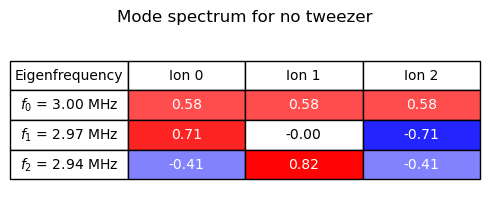

In [311]:
# Make figure and axis
fig, ax = plt.subplots(figsize=(5, 0.7 * len(base_modes)))
ax.axis('tight')
ax.axis('off')

# Prepare table data
table_data = []
for index, (omega, etas) in enumerate(base_modes):
    omega_mhz = omega / 1e6
    formatted_values = [f"{eta:.2f}" for eta in etas]
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ["Eigenfrequency"] + [f"Ion {i}" for i in range(len(base_modes))]

# Build the table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Style
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

# Colormap normalization
etas_all = np.concatenate([etas for _, etas in tweezed_modes])
vmax = np.max(np.abs(etas_all)) + 0.01
norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)
cmap = plt.get_cmap("bwr")

# Apply color to each η cell
for i in range(len(table_data)):
    for j in range(1, len(table_data[i])):  # skip frequency column
        value = float(table_data[i][j])
        color = cmap(norm(value))
        cell = table[i + 1, j]  # +1 to skip header
        cell.set_facecolor(color)
        cell.get_text().set_color("black" if -0.07 < value < 0.07 else "white")


table[0, 0].set_facecolor("white")

plt.tight_layout()
plt.title("Mode spectrum for no tweezer")
plt.show()


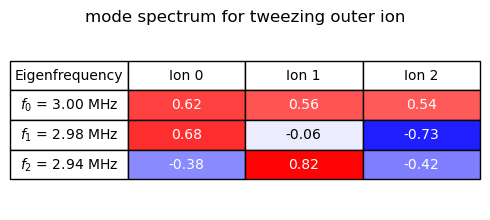

In [312]:
# Make figure and axis
fig, ax = plt.subplots(figsize=(5, 0.7 * len(tweezed_modes)))
ax.axis('tight')
ax.axis('off')

# Prepare table data
table_data = []
for index, (omega, etas) in enumerate(tweezed_modes):
    omega_mhz = omega / 1e6
    formatted_values = [f"{eta:.2f}" for eta in etas]
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ["Eigenfrequency"] + [f"Ion {i}" for i in range(len(tweezed_modes))]

# Build the table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Style
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

# Colormap normalization
etas_all = np.concatenate([etas for _, etas in tweezed_modes])
vmax = np.max(np.abs(etas_all)) + 0.01
norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)
cmap = plt.get_cmap("bwr")

# Apply color to each η cell
for i in range(len(table_data)):
    for j in range(1, len(table_data[i])):  # skip frequency column
        value = float(table_data[i][j])
        color = cmap(norm(value))
        cell = table[i + 1, j]  # +1 to skip header
        cell.set_facecolor(color)
        cell.get_text().set_color("black" if -0.07 < value < 0.07 else "white")


table[0, 0].set_facecolor("white")

plt.tight_layout()
plt.title("mode spectrum for tweezing outer ion")
plt.show()


## Tweezing the center ion

In [313]:
w_rf_r = 2*pi*3e6
w_rf_a = 2*pi*400e3
w_tw_r = 2*pi*150e3
w_tw_a = None
N = 3
w_comb_r = combined_frequencies(N,[1],w_tw_r,w_tw_a,w_rf_r,w_rf_a)[0]
w_comb_a = combined_frequencies(N,[1],w_tw_r,w_tw_a,w_rf_r,w_rf_a)[2]
ueq = ion_spacing(N,w_rf_a)[0]
base_modes = individual_freqs_to_mode_vectors(N,[1],0,0,w_rf_r,w_rf_a,ueq)
tweezed_modes = individual_freqs_to_mode_vectors(N,[1],w_tw_r,w_tw_a,w_rf_r,w_rf_a,ueq)

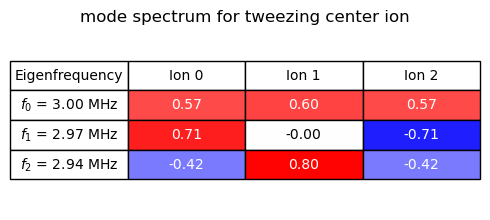

In [314]:
# Make figure and axis
fig, ax = plt.subplots(figsize=(5, 0.7 * len(tweezed_modes)))
ax.axis('tight')
ax.axis('off')

# Prepare table data
table_data = []
for index, (omega, etas) in enumerate(tweezed_modes):
    omega_mhz = omega / 1e6
    formatted_values = [f"{eta:.2f}" for eta in etas]
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ["Eigenfrequency"] + [f"Ion {i}" for i in range(len(tweezed_modes))]

# Build the table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Style
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

# Colormap normalization
etas_all = np.concatenate([etas for _, etas in tweezed_modes])
vmax = np.max(np.abs(etas_all)) + 0.01
norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)
cmap = plt.get_cmap("bwr")

# Apply color to each η cell
for i in range(len(table_data)):
    for j in range(1, len(table_data[i])):  # skip frequency column
        value = float(table_data[i][j])
        color = cmap(norm(value))
        cell = table[i + 1, j]  # +1 to skip header
        cell.set_facecolor(color)
        cell.get_text().set_color("black" if -0.07 < value < 0.07 else "white")


table[0, 0].set_facecolor("white")

plt.tight_layout()
plt.title("mode spectrum for tweezing center ion")
plt.show()


# Change in mode frequencies from varying optical power of tweezer beam

In [315]:
#This cell just checks my math with Jerry's math to do the power sweep
P_opt = 96e-3
w0 = 4e-6 #2 um beam diameter was quoted but my numbers only match Jerry's numbers if w0=4 um
pot = potential(omega_tweezer,linewidths,omega_res,P_opt,w0) #calculating the dipole potential from both S-P transitions
print(pot)
(omega_tweezer_r(pot,w0,mBa137)/2*pi)/1e3 #kHz #calculates optical trap frequency based off a Taylor expansion at x=y=z=0 of the beam

-8.311132991617944e-27


150.1704647547299

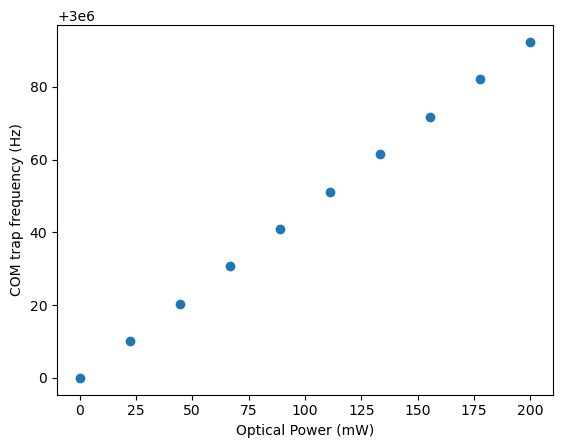

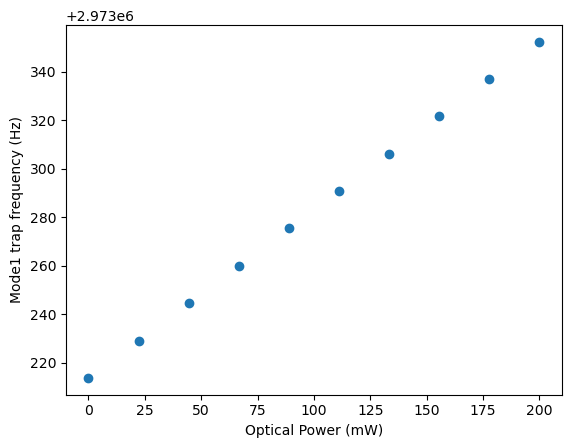

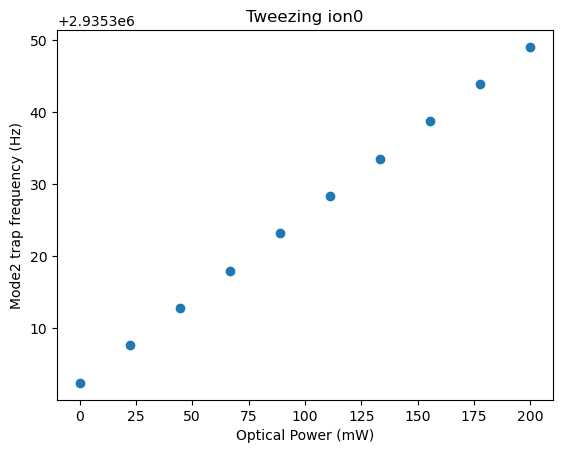

In [316]:
#going to sweep over powers from 0 mW to 200 mW and make 3 plots for 3 different ion positions
N = 3
P_opt = np.linspace(0,200e-3,10)
w0=4e-6
tweeze_0 = []
Modes = []
for P in range(len(P_opt)):
    tweeze_0.append(physical_params_to_radial_mode_vectors(N,ueq,[0],tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt[P],w0,m,potential(omega_tweezer,linewidths,omega_res,P_opt[P],w0)))
        # Get modes for the tweezed system (both ions tweezed simultaneously)
COM_frequencies = np.array([tweeze_0[i][0][0] for i in range(len(P_opt))]) #Hz
plt.scatter(P_opt*1e3,COM_frequencies)
plt.xlabel("Optical Power (mW)")
plt.ylabel("COM trap frequency (Hz)")
plt.show()
Mode1_frequencies = np.array([tweeze_0[i][1][0] for i in range(len(P_opt))]) #Hz

plt.scatter(P_opt*1e3,Mode1_frequencies)
plt.xlabel("Optical Power (mW)")
plt.ylabel("Mode1 trap frequency (Hz)")
plt.show()
Mode2_frequencies = np.array([tweeze_0[i][2][0] for i in range(len(P_opt))]) #Hz

plt.scatter(P_opt*1e3,Mode2_frequencies)
plt.xlabel("Optical Power (mW)")
plt.ylabel("Mode2 trap frequency (Hz)")
plt.title("Tweezing ion0")
plt.show()

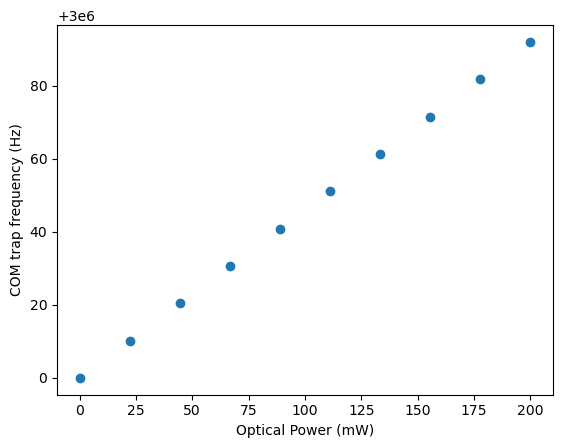

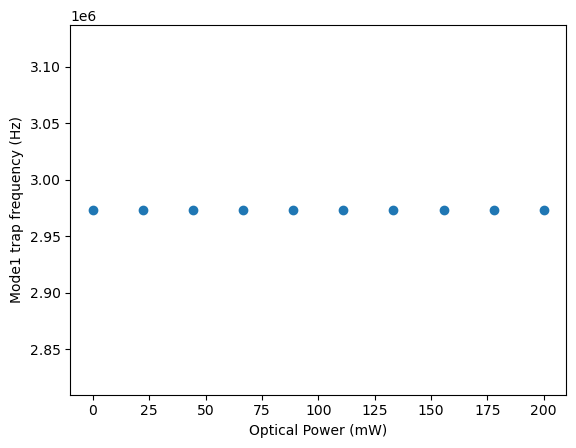

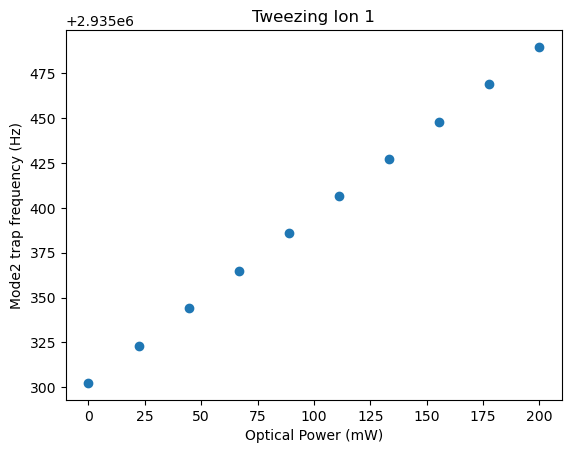

In [317]:
#going to sweep over powers from 0 mW to 200 mW and make 3 plots for 3 different ion positions
N = 3
P_opt = np.linspace(0,200e-3,10)
w0=4e-6
tweeze_0 = []
Modes = []
for P in range(len(P_opt)):
    tweeze_0.append(physical_params_to_radial_mode_vectors(N,ueq,[1],tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt[P],w0,m,potential(omega_tweezer,linewidths,omega_res,P_opt[P],w0)))
        # Get modes for the tweezed system (both ions tweezed simultaneously)
COM_frequencies = np.array([tweeze_0[i][0][0] for i in range(len(P_opt))]) #Hz
plt.scatter(P_opt*1e3,COM_frequencies)
plt.xlabel("Optical Power (mW)")
plt.ylabel("COM trap frequency (Hz)")
plt.show()
Mode1_frequencies = np.array([tweeze_0[i][1][0] for i in range(len(P_opt))]) #Hz

plt.scatter(P_opt*1e3,Mode1_frequencies)
plt.xlabel("Optical Power (mW)")
plt.ylabel("Mode1 trap frequency (Hz)")
plt.show()
Mode2_frequencies = np.array([tweeze_0[i][2][0] for i in range(len(P_opt))]) #Hz

plt.scatter(P_opt*1e3,Mode2_frequencies)
plt.xlabel("Optical Power (mW)")
plt.ylabel("Mode2 trap frequency (Hz)")
plt.title("Tweezing Ion 1")
plt.show()